### Potential Evapotranspiration, Total Alkalinity & Electrical Conductance Exploratory Data Analysis

This analysis explores spatial and environmental factors associated with river water quality. Satellite imagery from climate variables, such as Potential Evapotranspiration (PET) were incorporated to provide broader environmental context around observed water quality conditions and reflect underlying climatic influences. The analysis focuses on data collected between 2011 and 2015. Relevant satellite and climate features were retrieved using API-based access through the Microsoft Planetary Computer portal and combined with water quality observations. Together, these datasets support an exploratory assessment of three key water quality parameters. 

In this notebook, I'll explore how measurements of Potential Evapotranspiration (PET), Electrical Conductance (EC) and Total Alkalinity (TA) are distributed spatially across South Africa.

#### Load Dependencies

```%pip install geopandas folium seaborn watermark```

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import MultiPolygon
import folium
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from utils import ideal_wq

sns.set_theme()
sns.set_style('whitegrid', {'axes.grid': False})

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

%load_ext watermark
%watermark -v
%watermark --iversions

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.4.0

geopandas : 1.1.2
seaborn   : 0.13.2
pandas    : 2.3.1
shapely   : 2.1.2
folium    : 0.20.0
numpy     : 2.3.2
matplotlib: 3.10.5



#### Define functions

In [2]:
def spatial_plot_PET(provinces, gdf, var1='geometry', var2='province', var3='pet',var4='pop_density_nn',
                     title='Potential Evapotranspiration at Sampling Locations', legend_kwds={'label':'PET (mm/day)'}):
    '''
    Plots Chloropleth
    input
    -----
    - df: geopandas dataframe
    - var1: str
    - var2: str
    - var3: str
    - var4: str
    - title: str
    - legend_kwds: dict
    
    return
    ------
    Cloropleth
    '''
    # Plot
    fig, ax = plt.subplots(figsize=(11, 7))
    
    # Province Map
    provinces.plot(ax=ax, color='#B6B6B6')
    provinces['coords'] = provinces[var1].apply(lambda x: x.representative_point().coords[:])
    provinces['coords'] = [coords[0] for coords in provinces['coords']]
    for idx, row in provinces.iterrows():
        plt.annotate(text=row[var2], xy=row['coords'], horizontalalignment='center', color='white')
    #https://medium.com/nerd-for-tech/labelling-areas-of-coordinates-with-geopandas-74d25c8aada6
    
    # Overlay PET Data
    gdf.plot(column=var3, ax=ax, marker='o', markersize=gdf[var4], cmap='Blues', vmin=0, legend=True, legend_kwds=legend_kwds) #
    
    ax.set_axis_off() # leave the axis to see correlation between position and PET value
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show();


def spatial_plot_AT_EC(df, gdf, col1:str='electrical conductance', col2:str='total alkalinity', var:str='pop_density_nn', plot_unideal=False,
                       title:str='Population Density, TA & EC at Sampling Locations', legend_kwds1=dict, legend_kwds2=dict):
    '''
    Layer scatter plot onto chloropleth map with legends and preattentive attributes
    input
    -----
    - df: geopandas dataframe
    - col1: str
    - col2: str
    - var1: str
    - plot_unideal: bool
    - title: str
    - legend_kwds1: dict
    - legend_kwds2: dict
    
    return
    ------
    GeoPandas Plot
    '''

    fig, ax = plt.subplots(figsize=(11, 7))
    
    # Set up color map
    cmap1 = LinearSegmentedColormap.from_list("mycmap", ['#B6B6B6','#DB7629'])
    cmap2 = LinearSegmentedColormap.from_list("mycmap", ['#B6B6B6','#0E86E0'])
    
    df.plot(column=col1, ax=ax, zorder=1, cmap=cmap1, alpha=0.6, vmin=0, legend=True, legend_kwds=legend_kwds1)
    gdf.plot(column=col2, ax=ax, marker='o', markersize=gdf[var], cmap=cmap2, vmin=0, legend=True, legend_kwds=legend_kwds2)
    
    if plot_unideal == True:
        unideal_wq.plot(column='unideal', ax=ax, marker='^', markersize=100, color='red')
    else:
        pass

    ax.set_axis_off()
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show();


def piv(df, x='province', y='pet', by='province'):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    pandas dataframe pivot grouped by x and values sorted by y
    '''
    df = df[[x, y]].groupby(x).mean().sort_values(by=by, ascending=True)
    df = df[y].round().astype(int)
    return df.reset_index();


def bar_horizontal(df, x='province', y='pet', title=str):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    matplotlib horizontal bar plot
    '''
    fig, ax = plt.subplots(figsize=(12, 5))
    plt.barh(df[x], df[y].round().astype(int), xerr=None, color='#0E86E0')
    ax.set_xticklabels(labels=df[y])
    plt.get_cmap('viridis')
    plt.title(title);

#### Load Data

- Final dataset from pickle format including feature engineered ideal water quality attributes
- Shapefile for information on province geometry in South Africa

All the data will be read into GeoDataFrames, which have columns for geographic location and areas. This is useful for plotting maps.

https://simplemaps.com/gis/country/za --> download shapefile  
https://simplemaps.com/static/svg/country/za/admin1/za_shp.zip

In [3]:
# From our final dataset, add some quality parameters from information about whether values belong to an ideal range
df = ideal_wq.ideal_wq('data/wq.csv')

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)
print('Variables we can work with:',list(gdf.columns),'\n')

# isolate all sample locations with "unideal" water quality into a separate dataframe
unideal_wq = gdf[gdf['unideal']==1]
# unideal_wq = gdf[gdf['bad']==1] # change language to mitigate possible harm
print('There are',len(unideal_wq),'datapoints representing water quality values of Total Alkalinity, Electrical Conductance & Dissolved Reactive Phosphorous that lie outside the ideal range provided to us by the data source.')

path_to_data = 'data/za_shp'
provinces = gpd.read_file(path_to_data, layer='za').to_crs("EPSG:4326")
provinces = provinces.rename(columns={'name':'province'}).sort_values(by='province')

Variables we can work with: ['country', 'latitude', 'longitude', 'sample date', 'nir', 'green', 'swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'total alkalinity', 'electrical conductance', 'dissolved reactive phosphorus', 'month', 'province', 'sample_year', 'pop_density_nn', 'distance_km_to_pd_cell', 'river_mouth', 'river_junction', 'river_mouthORjunction', 'DRP', 'EC', 'Alkalinity', 'how_good', 'ideal', 'unideal', 'geometry'] 

There are 220 datapoints representing water quality values of Total Alkalinity, Electrical Conductance & Dissolved Reactive Phosphorous that lie outside the ideal range provided to us by the data source.


We used GeoPandas to load the data above, which creates an oject similar to a PandasDataFrame. The main difference is that it adds a geometry feature that could contain a geographical point, polygon or multipolygon using spatial data.  
The Western Cape of South Africa includes the Prince Edwards Islands. We don't have any water quality data from this region, so I decided to exclude its area in the GeoPandasDataFrame.

I broke down and had to ask AI how to do the next step <a href="https://search.brave.com/ask?q=poly+geometry+column+attributes+geopandas&source=quick-answer-followup&quickAnswerKey=08b6a94cb59b797c37ab73c2288ac22f4a90&quickAnswerQuery=poly+geometry+column+attributes+geopandas&conversation=08b68984eb40a57f229ccbefc071d17a3b3c">here</a>, and promted it as such, "how to convert a multipolygon geometry into a polygon geopandas".  
The original MULTIPOLYGON geometry for the Western Cape consisted of 3 POLYGONS. I got rid of one of them, so it is still a MULTIPOLYGON, just with 2/3 POLYGONS.

In [4]:
# replace the Western Cape with just the main land, without PRINCE EDWARDS ISLANDS
new_polygon = provinces['geometry'].explode()[7][:1]
multipolygon = MultiPolygon(new_polygon)
provinces.loc[7, 'geometry'] = multipolygon
provinces

,id,province,source,geometry
3,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758..."
2,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592..."
8,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940..."
1,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729..."
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963..."
6,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297..."
5,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070..."
0,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129..."
7,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -..."


#### 1. Grouping water quality parameters by province and aggregate by mean

Evapotranspiration is the *combined* process of how moisture is transferred from the land level into the atmosphere.
This metric is often related to weather, climate & **water availability**.
- evaporation: water from the Earth's surface
- transpiration: water vapor from plants

Potential Evapotranspiration measurements may reflect temperature, humidity and vegetation type in any given region, measured in mm/day.  

https://en.wikipedia.org/wiki/Potential_evapotranspiration  
https://planetarycomputer.microsoft.com/dataset/terraclimate#overview

##### a) Chloropleth Map (PET)

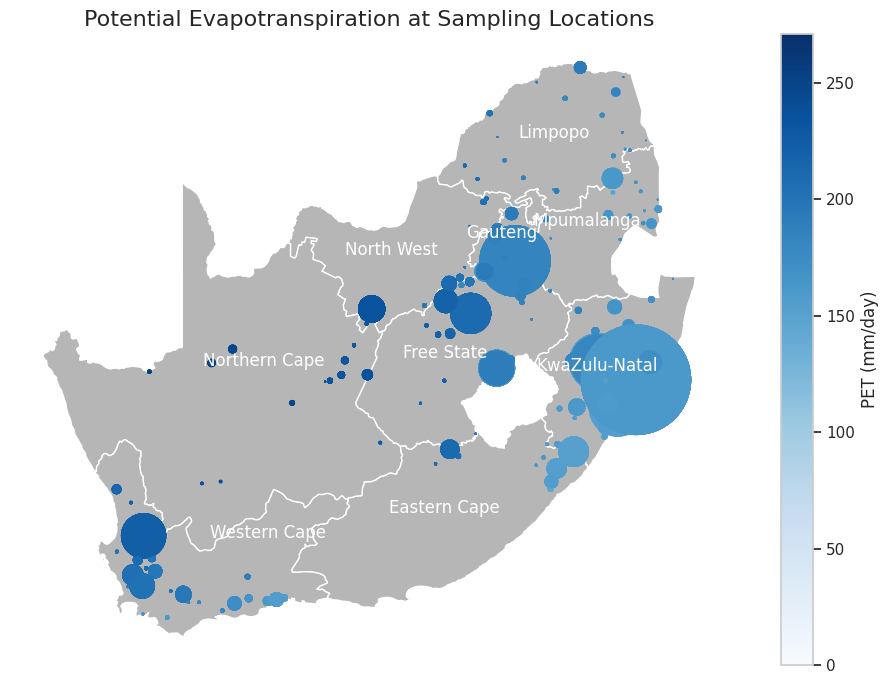

In [5]:
spatial_plot_PET(provinces, gdf, var1='geometry', var2='province', var3='pet',var4='pop_density_nn', title='Potential Evapotranspiration at Sampling Locations', legend_kwds={'label':'PET (mm/day)'})

In [6]:
print('Supplemental Descriptive Statistics about PET values from our dataset')
round(pd.DataFrame(df['pet'].describe()), None).astype(int)

Supplemental Descriptive Statistics about PET values from our dataset


,pet
count,9093
mean,175
std,29
min,53
25%,156
50%,172
75%,193
max,271


#### Observation and Analysis

PET values are encoded using color. The higher the PET value, the lighter the color becomes. It seems like PET value increases from east to west.

Potential Evapotranspiration is usually measured indirectly using other climactic factors, like the amount of Water Volume Evapotranspired from a sample location (mm day<sup>−1</sup>) during a specific time period. PET is dependent on temperature and vapor pressure. As the global temperature increases PET and humidity increase with it.  
Relative humidity could be merged with our dataset in the future for verification of this insight.

Uncomment the code snippet below; the green areas representing more vegetative regions are mirroring the lower (darker) PET values above. This suggests that in areas with more vegetation, and possibly more humidity, water is less likely to transpire or evaporate. Further west, PET values are higher, which indicates a higher chance of transpiration/evaporation. Not surprisingly, the map below shows less vegetation in those same areas of the spatial plot where PET values are higher.

In [7]:
# folium.Map(location=[-29.6,25.1], zoom_start=6, tiles='USGS.USImagery')

##### b) The horizontal barplot below shows average PET values for each province in South Africa

You can more easily compare the PET values among each province by observing the bar graph below.

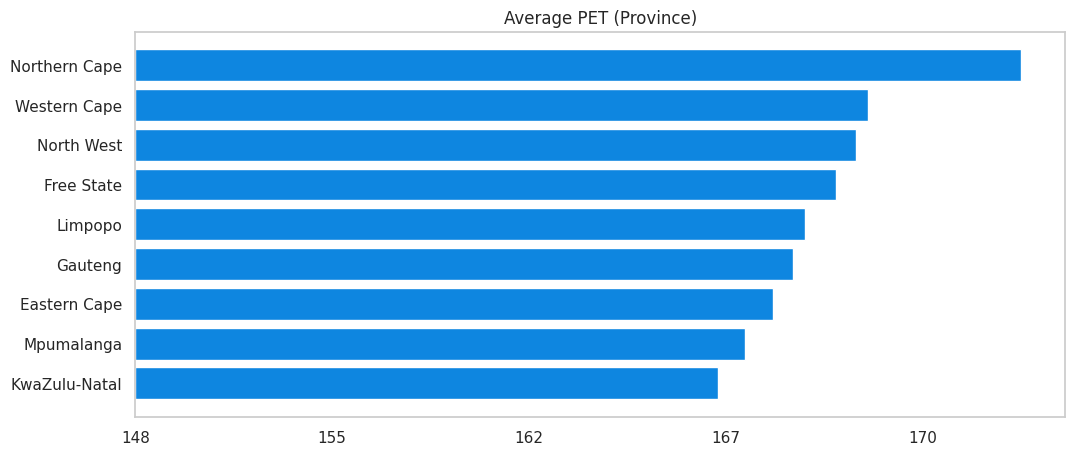

In [8]:
bar_horizontal(piv(gdf, y='pet', by='pet'), title='Average PET (Province)')

##### Wait...

Call the function again changing the 'y' and 'by' parameters (```bar_horizontal(piv(gdf, y='pet', by='pet')```). 'y' and 'by' should be equal, so the bar graph will sort the provinces by value of the given parameter. Here are some inputs to choose from:

- 'nir'
- 'green'
- 'swir16'
- 'swir22'
- 'ndmi'
- 'mndwi'
- 'pet'
- 'total alkalinity'
- 'electrical conductance'
- 'dissolved reactive phosphorus'

In [9]:
# Now group by province and aggregate by mean electrical conductance
province_group_EC = piv(df, x='province', y='electrical conductance', by='province')
province_group_TA = piv(df, x='province', y='total alkalinity', by='province')

# Then add aggregated EC data to each provice
provinces = provinces.merge(province_group_EC, on='province')
provinces = provinces.merge(province_group_TA, on='province')
provinces

,id,province,source,geometry,coords,electrical conductance,total alkalinity
0,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758...","(26.577065663967588, -32.09173588687274)",243,104
1,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592...","(26.606093829957928, -28.668094454343883)",561,144
2,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940...","(28.020037358470212, -26.00964140017083)",622,135
3,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729...","(30.414604593508667, -28.941989809339603)",240,71
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963...","(29.33324092059666, -23.781743005039885)",475,119
5,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297...","(30.160392842076874, -25.740029807867035)",374,111
6,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070...","(25.243374195623897, -26.37090424293574)",727,186
7,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129...","(22.022202804943113, -28.846199726745684)",633,149
8,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -...","(22.149666213053404, -32.64267849889474)",494,62


#### Total Alkalinity & Electrical Conductance

- Total Alkalinity
    - Resistance to pH fluctuation often measured by buffer concentrations of CaCO3 (or similar titrant) in milligrams per liter or ppm. 
    -  Ideal Range: 20 to 200 mg/L  
- Electrical Conductance
    - How easily electric current flows through a specific object or component, measured in micro-Siemens per centimeter. EC value can tell us the water's ability to conduct an electrical current. The more dissolved ions in the water, the higher the conductivity.
    - Ideal Range: < 800 µS/cm

https://www.usgs.gov/water-science-school/science/alkalinity-and-water  
https://www.boquinstrument.com/a-understanding-the-relationship-between-conductivity-and-water-quality.html


##### **Encodings**

Population Density is encoded using **size**, while water quality parameters (TA and EC) are encoded using **color**. The circular marks' colorscale represent Total Alkalinity (blue) and Electrical Conductance is represented by the color of the outlined provinces (orange).

##### c) Chloropleth (TA & EC)

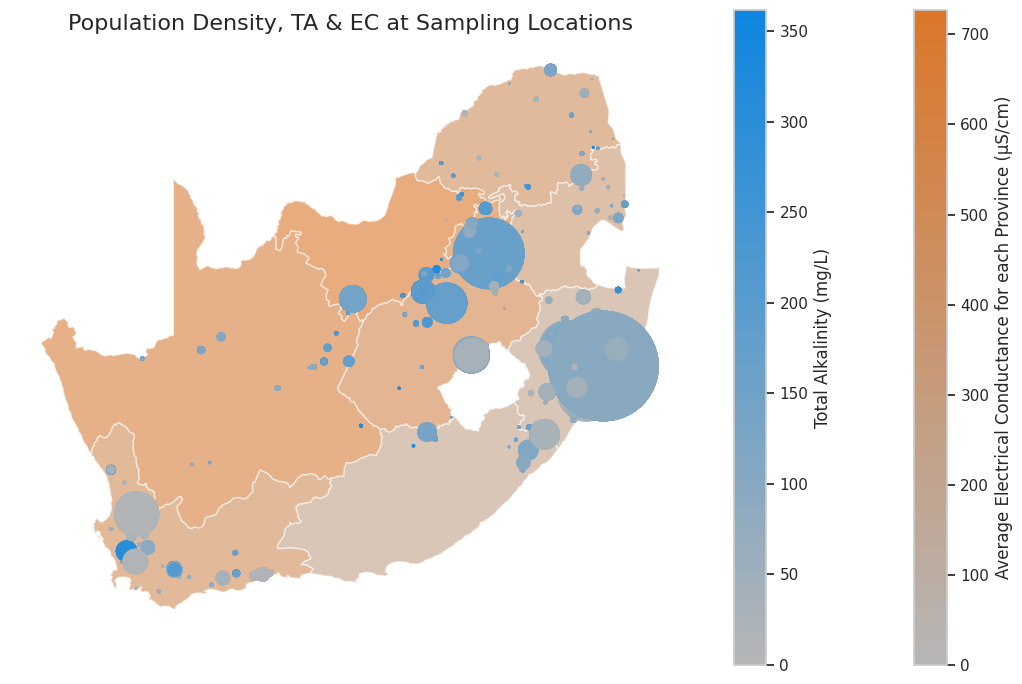

In [10]:
legend_kwds1={'label':'Average Electrical Conductance for each Province (µS/cm)'}
legend_kwds2={'label':'Total Alkalinity (mg/L)'}

spatial_plot_AT_EC(provinces, gdf, col1='electrical conductance', col2='total alkalinity', plot_unideal=False, legend_kwds1=legend_kwds1, legend_kwds2=legend_kwds2)

#### Observation and Analysis

Like PET, EC values are higher in the west than in the east. Total Alkalinity values are depicted slightly lower in the south than the north. Same as the observation above about PET, I think water quality fluctuates due to climactic factors in South Africa.
Higher EC means there is a higher concentration of dissolved substances. It cannot be assumed, given the raw measurement of EC, that the dissolved substances present are beneficial to its water quality. It purely represents the concentration of ions in water. That being said, drinking water with excessively high levels of certain ions can lead to health risks.

Alkalinity, on the other hand, describes a water sample sources buffering capacity. The presence of buffers in water help maintain stable pH levels, which is essential for aquatic life. Buffers are chemical compounds, like bicarbonates, carbonates and hydroxides that can react with acids or bases to keep the pH in a particular range. Basically, if a body of water has stable pH, it is a good indicator of the water's quality. There is actually no upper or lower limit for alkalinity in drinking water, but the recommended pH for drinking water lies between 6.5 - 8.5.

One interesting thing to point out is population density doesn't seem to affect these water quality measurements. There are large circle marks with low values and vice versa. The function above allows for the parameters col1 and col2 to be swapped in order to observe the circular marks' colorscale to represent EC and the provinces colorscale to represent TA. The resulting map is very similar, maybe even redundant.

#### 2. Correlation

##### a) It looks like Total Alkalinity and Electrical Conductance have a moderate positive correlation

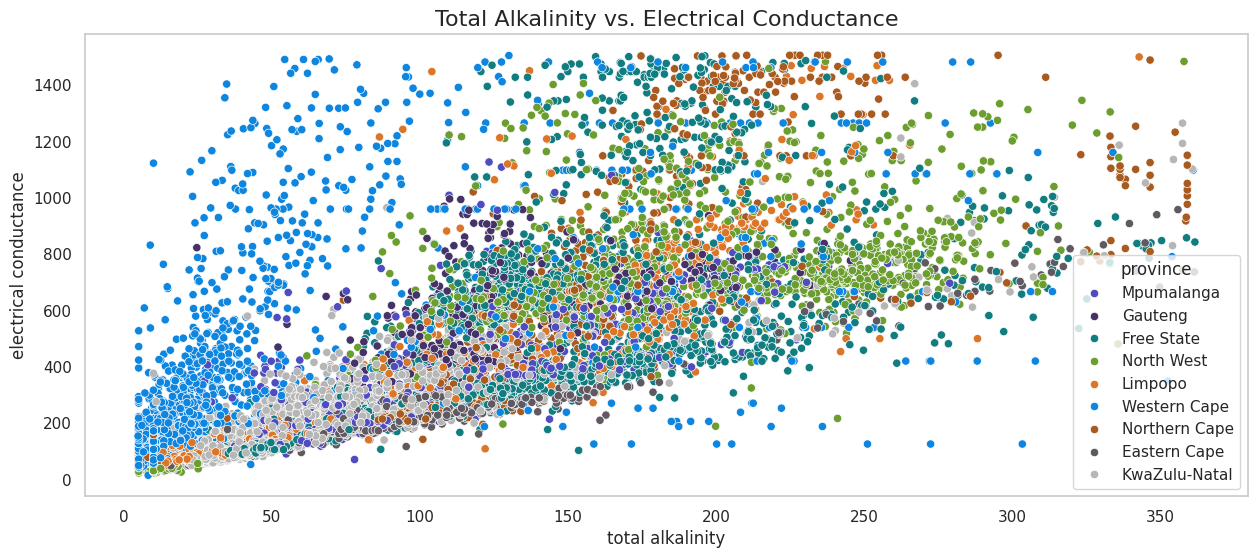

In [11]:
colors = ['#4F4CC0','#453268','#127D80','#6B9D2F','#DB7629','#0E86E0','#A85A1F','#605962','#B6B6B6']

fig, ax = plt.subplots(figsize=(15, 6))
sns.scatterplot(data=gdf, x="total alkalinity", y="electrical conductance", hue='province', palette=colors)
plt.title("Total Alkalinity vs. Electrical Conductance", fontsize=16);

**Caption: as the buffering capacity of water increases, the concentration of dissolved ions in that water also increases. Here we observe a direct relationship between TA and EC.**

##### b) Correlation Matrix

In [12]:
df.columns = ['country', 'latitude', 'longitude', 'sample date', 'nir', 'green',
       'swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'TA', 'EC', 'DRP', 'month',
       'province', 'sample_year', 'pop_density_nn', 'dist_km_to_pd',
       'river_mouth', 'river_junction', 'mouthORjunction', 'drp_ok', 'ec_ok',
       'ta_ok', 'how_good', 'ideal', 'unideal']

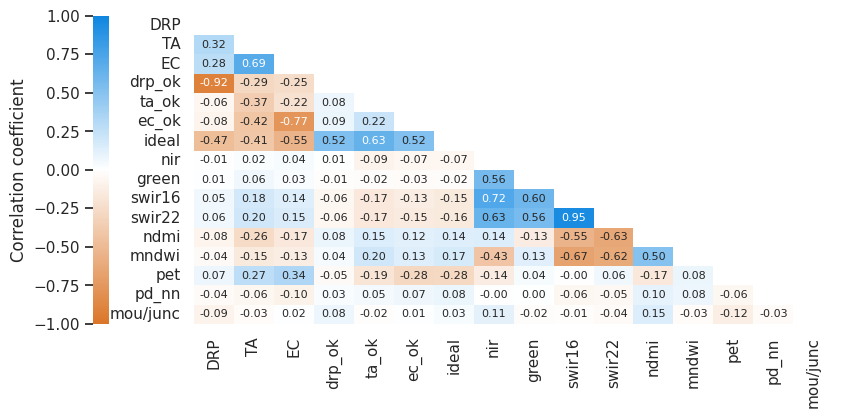

In [25]:
# Observing patterns of correlation is easier when plotted

df.columns = ['country', 'latitude', 'longitude', 'sample date', 'nir', 'green',
       'swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'TA', 'EC', 'DRP', 'month',
       'province', 'sample_year', 'pd_nn', 'dist_km_to_pd',
       'river_mouth', 'river_junction', 'mou/junc', 'drp_ok', 'ec_ok',
       'ta_ok', 'how_good', 'ideal', 'unideal']

cols = [
    "DRP", "TA", "EC",
    "drp_ok", "ta_ok", "ec_ok", "ideal",
    "nir", "green", "swir16", "swir22",
    "ndmi", "mndwi",
    "pet",
    "pd_nn",
    "mou/junc"
]

# Select only numnerical columns
# corr = df.select_dtypes(include=float).corr()
corr = df[cols].corr()

# Set colors and cbar_kws
cmap = LinearSegmentedColormap.from_list("mycmap", ['#DB7629', '#FFFFFF', '#0E86E0'])
cbar_kws = dict(label='Correlation coefficient', use_gridspec=False, location="left")

# Create a mask using numpy's triu function
# https://www.datacamp.com/tutorial/seaborn-heatmaps
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(corr, cmap=cmap, vmin=-1, vmax=1, center=0, annot=True, mask=mask, fmt=".2f", annot_kws={"size": 8}, cbar_kws=cbar_kws)#, cbar_kws={"label": "Correlation coefficient"})

# plt.title('Correlation Matrix');

# Save the plot as a PNG file
plt.savefig('data/plot.png', dpi=300, bbox_inches='tight', transparent=True)

**Caption: The darker, more opaque colors represent variable pairs that have a stronger correlation than the lighter colors that fade, and whose values are closer to zero. Pearsons Correlation ranges from -1 to 1 as shown in the legend.**

#### Observation and Analysis

In the color coded scatter plot, you can distinguish each province and their unique range of values when comparing the relationship between TA and EC. In order to gain more concrete insights on the nature of TA and EC values, we need to observe each province separately.

There are generally no strong correlations. The land satellite data (nir, green, swir16, swir22, ndmi, mndwi) have the strongest correlations amongst each other, suggesting they could be redundant in some cases. Total alkalinity and Electrical have a realtively moderate correlation. There is also some geografical correlation, for example, PET is negatively correlated with longitude while total alkalinity and DRP have a slightly positive correlation with latitude.  

- PET values are generally increasing from East to West.
- If you refer back to the map visualization above, you'll notice the encoded range of values for total alkalinity change ever so slightly when observing the data points' color from south to north suggesting a weak to moderate, direct relationship with latitude.

#### 4. How do our parameters relate to time?

##### a) Timeline

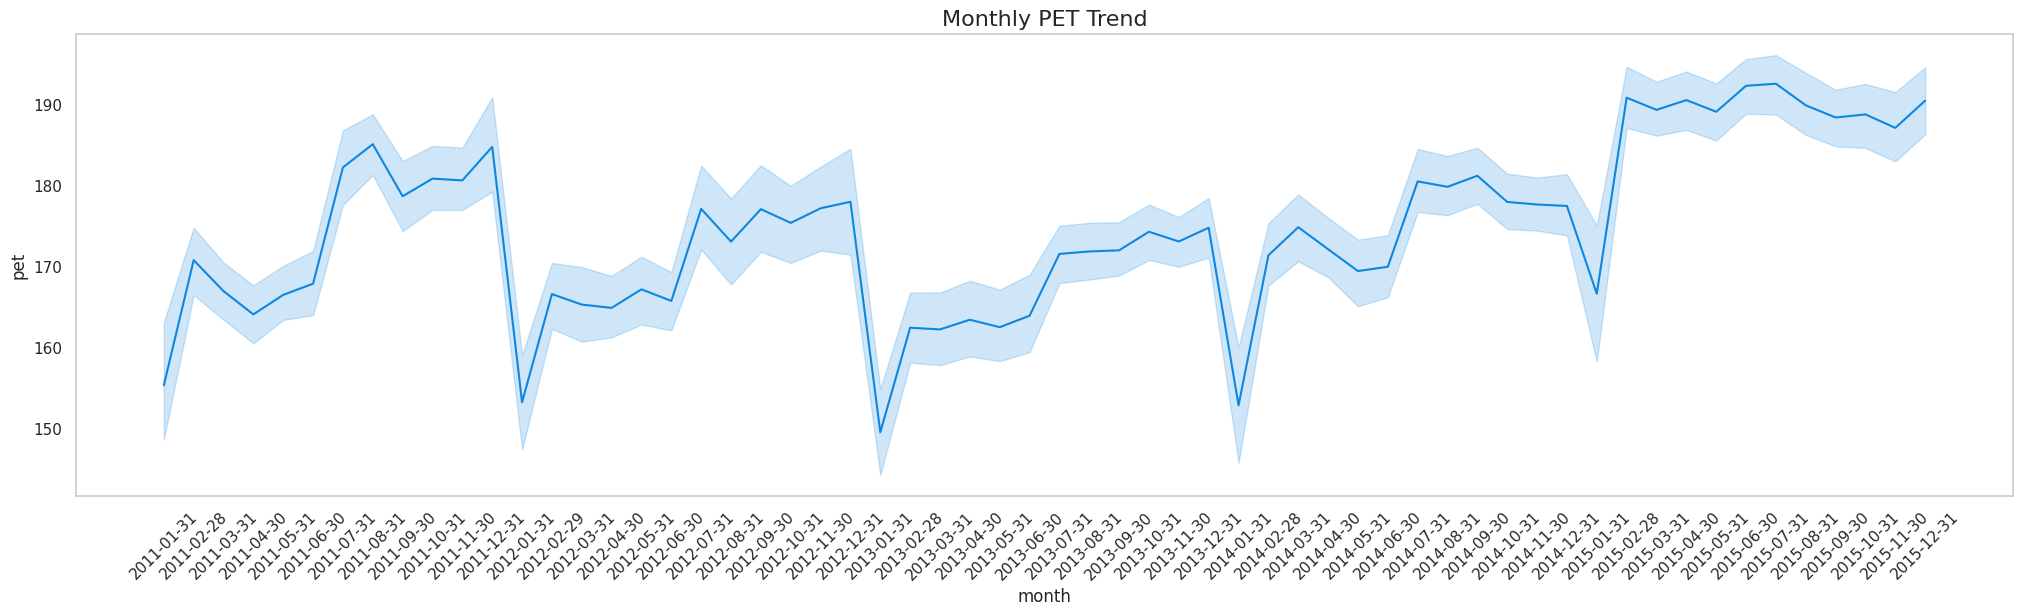

In [14]:
# Monthly time series vs PET (make sure to sort values by month)*
gdf = gdf.sort_values(by='month')

fig, ax = plt.subplots(figsize=(25, 6));
sns.lineplot(data=gdf, x="month", y="pet", color=colors[5])
plt.xticks(rotation=45)
plt.title('Monthly PET Trend', fontsize=16);

**Earlier I mentioned PET depends on temperature. Here we can see the temperature is dropping every December (the beginning of summer in the southern hemisphere), except for in 2015, which is the last year we have access to. We need more data beyond 2015 to see whether this temperature-related-trend continued.**

##### b) Time Scatter

NOTE: This is the same data as visualized above. However, in a seaborn styled scatterplot, the data are binned by month.

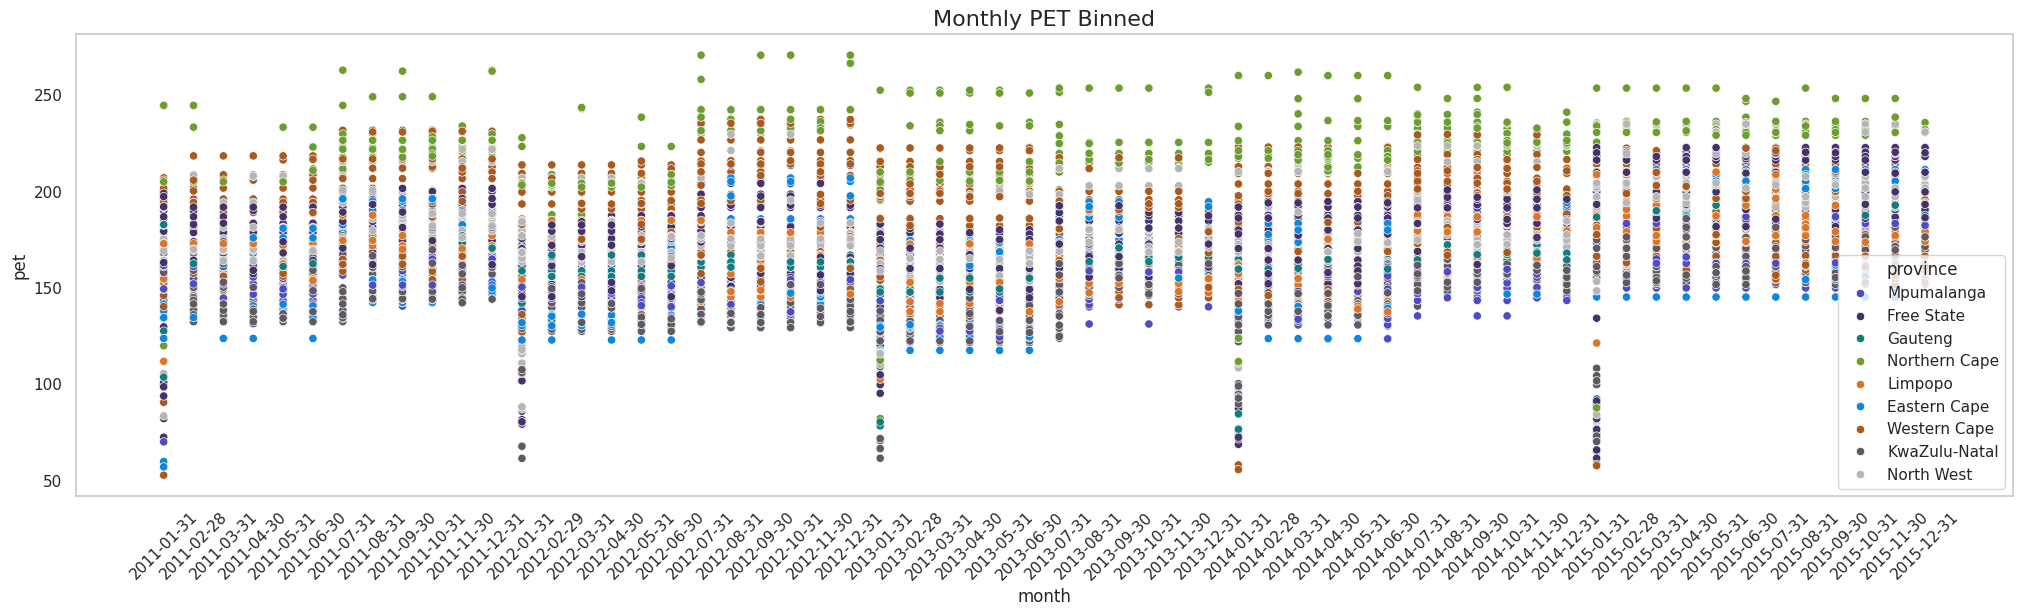

In [15]:
fig, ax = plt.subplots(figsize=(25, 6));
sns.scatterplot(data=gdf, x="month", y="pet", hue='province', palette=colors)
plt.xticks(rotation=45)
plt.title('Monthly PET Binned', fontsize=16);

**Interestingly, the values of each parameter are falling around the same period (~December of each year). South Africa is in the Southern Hemisphere, which has opposite seasons than many are used to, north of the equator.**

##### c) Monthly Average Water Quality Parameters

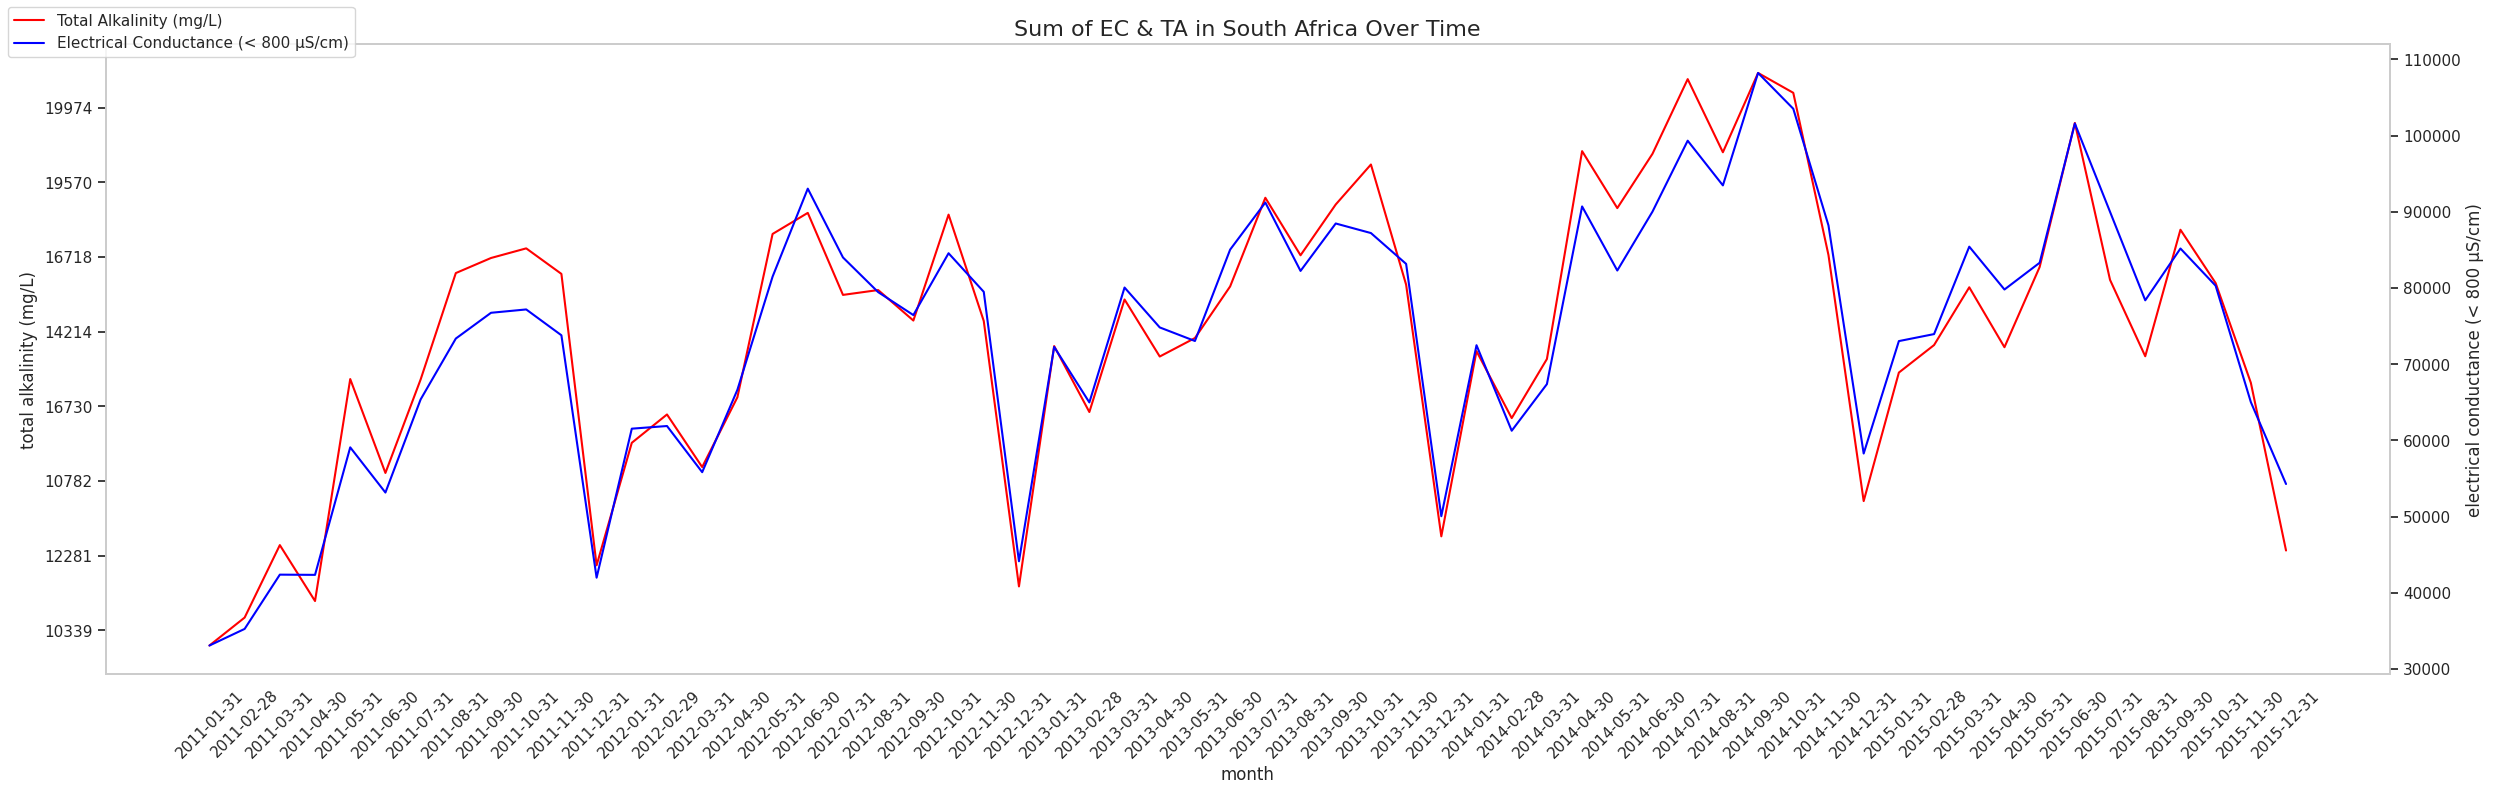

In [16]:
# create alternative time series data to plot (GROUPBY MONTH; AGGREGATE by SUM)
pivot_table1 = gdf[['total alkalinity', 'electrical conductance', 'month']].groupby('month').sum().astype(int)

# add units for clarity: TA: mg/L, EC: µS/cm
pivot_table1.columns = ['total alkalinity (mg/L)', 'electrical conductance (< 800 µS/cm)']

# Initialize Figure
fig, ax = plt.subplots(figsize=(25, 8))

# Create the secondary axis
ax2 = ax.twinx()

# Plot
sns.lineplot(pivot_table1, x='month', y='total alkalinity (mg/L)', ax=ax, color='red', label='Total Alkalinity (mg/L)', legend=False)#
sns.lineplot(pivot_table1, x='month', y='electrical conductance (< 800 µS/cm)', ax=ax2, color='blue', label='Electrical Conductance (< 800 µS/cm)', legend=False)

ax.set_xticklabels(pivot_table1.reset_index()['month'], rotation=45)
ax.set_yticklabels(pivot_table1['total alkalinity (mg/L)'])
plt.title('Sum of EC & TA in South Africa Over Time', fontsize=16)
fig.legend(loc='upper left')
plt.tight_layout()
plt.show();

# dual yaxis => leads to a lot of clutter when trying to visualize more than 2 variables

#### Observation and Analysis

There are 5 distinct periods where PET values are systemically low, relative to the rest of the trend. Since PET is related to temperature, it could be inferred that the temperature may also be dropping during this period in South Africa. "In South Africa, the rainy season generally begins in October and ends in April". Maybe at the end of 2015, it was drier than usual. Continued data is needed to find out whether this trend had continued into later years.

Non-coincidentally, Electrical Conductance and Total Alkalinity values drop around the same period, just one month in advance. The plot could indicate a change in climate at the end of each year in South Africa. If there is much rainfall during this time period, then that could have an impact dissolved ion concentration and 

https://aswica.co.za/when-is-the-rainy-season-in-south-africa-here-s/

#### Conclusion:

In conclusion, there aren't enough key features available within the data to determine conclusive water quality of the sampling locations. Ideally, we would need to add sources of additional information to accompany our data including pH level, other chemical/microbiological parameters and water temperature for an extended period after the end of 2015. Since the available time period is set between the beginning of 2011 until end of 2015, our observation is limited. The continuance or drifting of the reoccurring trend of water quality values dropping at the end of each calendar year merits acquiring future data relative to the dataset of our analysis.  

EC and TA are directly correlated, and their relationship can be described as moderate. This means the concentration of ions and presence of buffers in the water have a positive correlation. PET has an inverse, moderate correlation with longitude, meaning that the value increases from the east to the west side of the country.